#**Football Data Processing**



## Step 1: Import the relevant original dataset

We import the unprocessed dataset to prepare it for analysis.
The original folder includes:
- matches.csv: Contains the id of teams, leagues, and matches.

- scores.csv: Contains the number of goals scored by the home team and the away team. Can be mapped with matches.csv through match_id

- leagues.csv: Contains the name of the leagues. Can be mapped with matches.csv through match.id

- teams.csv: Contains the name of the teams. Can be mapped with matches.csv through team_id

- standings.csv: Contains the standings of the leagues in the end. This file is not used to create anything in the report as it lacks the necessary statistics but is a good reference point to compare with the table that is generated with the analysis

In [ ]:
import pandas as pd

# load league metadata (league_id, name, etc.) from CSV
leagues = pd.read_csv('unprocessed/leagues.csv')
# load all match records across all leagues
matches = pd.read_csv('unprocessed/matches.csv')
# load goal counts
scores = pd.read_csv('unprocessed/scores.csv')
# load team_id -> team_name lookup
teams_df = pd.read_csv('unprocessed/teams.csv')

print("leagues.csv table: ")
display(leagues.head())
print("matches.csv table: ")
display(matches.head())
print("scores.csv table: ")
display(scores.head())
print("teams.csv table: ")
display(teams_df.head())

leagues.csv table: 


,league_id,name,country,country_id,icon_url,cl_spot,uel_spot,relegation_spot
0,2,Serie A,Italy,2,https://crests.football-data.org/SA.png,4,5,18
1,3,La Liga,Spain,3,https://crests.football-data.org/PD.png,4,5,18
2,4,Bundesliga,Germany,4,https://crests.football-data.org/BL1.png,4,5,16
3,5,Ligue 1,France,5,https://crests.football-data.org/FL1.png,3,4,17
4,1,Premier League,England,1,https://crests.football-data.org/PL.png,4,6,18


matches.csv table: 


,match_id,season_id,league_id,matchday,home_team_id,away_team_id,winner,utc_date
0,435943,1,1,1,328,65,AWAY_TEAM,2023-08-11
1,435944,1,1,1,57,351,HOME_TEAM,2023-08-12
2,435945,1,1,1,1044,563,DRAW,2023-08-12
3,435946,1,1,1,397,389,HOME_TEAM,2023-08-12
4,435947,1,1,1,62,63,AWAY_TEAM,2023-08-12


scores.csv table: 


,score_id,match_id,full_time_home,full_time_away,half_time_home,half_time_away
0,1,435943,0,3,0,2
1,2,435944,2,1,2,0
2,3,435945,1,1,0,0
3,4,435946,4,1,1,0
4,5,435947,0,1,0,0


teams.csv table: 


,team_id,name,founded_year,stadium_id,league_id,coach_id,cresturl
0,77,Athletic Club,1898.0,61,3,61,https://crests.football-data.org/77.png
1,78,Club Atlético de Madrid,1903.0,62,3,62,https://crests.football-data.org/78.svg
2,79,CA Osasuna,1920.0,63,3,63,https://crests.football-data.org/79.svg
3,81,FC Barcelona,1899.0,64,3,64,https://crests.football-data.org/81.svg
4,82,Getafe CF,1946.0,65,3,65,https://crests.football-data.org/82.png


## Step 2: Compute standings from match + score data
We merge matches with scores to get actual goals, then compute:
- **Overall**: won, draw, lost, points, goals_for, goals_against, goal_difference
- **Home**: home_won, home_draw, home_lost, home_points, home_goals_for, home_goals_against, home_goal_difference
- **Away**: away_won, away_draw, away_lost, away_points, away_goals_for, away_goals_against, away_goal_difference

In [ ]:
# build a lookup dict
league_map = dict(zip(leagues['league_id'], leagues['name']))

# merge matches with scores using match_id
df = matches.merge(scores[['match_id', 'full_time_home', 'full_time_away']], on='match_id', how='left')

print(f'Total matches after merge: {len(df)}')
print(f'Matches with missing scores: {df["full_time_home"].isna().sum()}')
df.head()

Total matches after merge: 1752
Matches with missing scores: 0


,match_id,season_id,league_id,matchday,home_team_id,away_team_id,winner,utc_date,full_time_home,full_time_away
0,435943,1,1,1,328,65,AWAY_TEAM,2023-08-11,0,3
1,435944,1,1,1,57,351,HOME_TEAM,2023-08-12,2,1
2,435945,1,1,1,1044,563,DRAW,2023-08-12,1,1
3,435946,1,1,1,397,389,HOME_TEAM,2023-08-12,4,1
4,435947,1,1,1,62,63,AWAY_TEAM,2023-08-12,0,1


In [ ]:
def compute_standings(match_df, league_id):
    """
    Given a DataFrame of matches (with full_time_home and full_time_away columns)
    for a single league, compute the full standings table.

    Statistics to be calculated:
    - Overall: won, draw, lost, points, goals_for, goals_against, goal_difference

    Points are calculated as follows: 3 points for a win, 1 point for a draw
    Goal Difference is calculated as goals_for - goals_against
    """
    all_teams = set(match_df['home_team_id'].unique()) | set(match_df['away_team_id'].unique())

    records = []
    for team in all_teams:      # loop through all teams and compute stats
        # home stats
        home_games = match_df[match_df['home_team_id'] == team]
        home_won = int((home_games['full_time_home'] > home_games['full_time_away']).sum())
        home_draw = int((home_games['full_time_home'] == home_games['full_time_away']).sum())
        home_lost = int((home_games['full_time_home'] < home_games['full_time_away']).sum())
        home_goals_for = int(home_games['full_time_home'].sum())
        home_goals_against = int(home_games['full_time_away'].sum())
        home_points = home_won * 3 + home_draw
        home_goal_difference = home_goals_for - home_goals_against

        # away stats
        away_games = match_df[match_df['away_team_id'] == team]
        away_won = int((away_games['full_time_away'] > away_games['full_time_home']).sum())
        away_draw = int((away_games['full_time_away'] == away_games['full_time_home']).sum())
        away_lost = int((away_games['full_time_away'] < away_games['full_time_home']).sum())
        away_goals_for = int(away_games['full_time_away'].sum())
        away_goals_against = int(away_games['full_time_home'].sum())
        away_points = away_won * 3 + away_draw
        away_goal_difference = away_goals_for - away_goals_against

        # overall stats
        won = home_won + away_won
        draw = home_draw + away_draw
        lost = home_lost + away_lost
        points = home_points + away_points
        goals_for = home_goals_for + away_goals_for
        goals_against = home_goals_against + away_goals_against
        goal_difference = goals_for - goals_against

        records.append({                # now append stats to the list
            'league_id': league_id, 'team_id': team,
            'won': won, 'draw': draw, 'lost': lost,
            'points': points,
            'goals_for': goals_for, 'goals_against': goals_against,
            'goal_difference': goal_difference,
            'home_won': home_won, 'home_draw': home_draw, 'home_lost': home_lost,
            'home_points': home_points,
            'home_goals_for': home_goals_for, 'home_goals_against': home_goals_against,
            'home_goal_difference': home_goal_difference,
            'away_won': away_won, 'away_draw': away_draw, 'away_lost': away_lost,
            'away_points': away_points,
            'away_goals_for': away_goals_for, 'away_goals_against': away_goals_against,
            'away_goal_difference': away_goal_difference,
        })

    standings = pd.DataFrame(records)
    standings = standings.sort_values(
        by=['points', 'goal_difference', 'goals_for'],
        ascending=[False, False, False]
    ).reset_index(drop=True)
    standings['position'] = standings.index + 1

    return standings

print('compute_standings() defined successfully.')

compute_standings() defined successfully.


In [ ]:
# compute standings for each league and save to processed/

all_standings = []
standing_id_counter = 1

for lid, lname in league_map.items():
    # filter matches for the current league
    league_df = df[df['league_id'] == lid]

    # compute the full standings table (overall + home/away splits)
    st = compute_standings(league_df, lid)

    # assign a unique standing_id to each row, continuing from the last league
    st['standing_id'] = range(standing_id_counter, standing_id_counter + len(st))
    standing_id_counter += len(st)

    all_standings.append(st)  # store for later concatenation

    # build the output file path from the league name (e.g. "premier_league_standings.csv")
    file_prefix = lname.lower().replace(' ', '_')
    filepath = f'processed/{file_prefix}_standings.csv'

    # define the exact column order for the CSV output
    col_order = [
        'standing_id', 'league_id', 'position', 'team_id',
        'won', 'draw', 'lost', 'points',
        'goals_for', 'goals_against', 'goal_difference',
        'home_won', 'home_draw', 'home_lost', 'home_points',
        'home_goals_for', 'home_goals_against', 'home_goal_difference',
        'away_won', 'away_draw', 'away_lost', 'away_points',
        'away_goals_for', 'away_goals_against', 'away_goal_difference'
    ]

    # write standings to CSV (without the pandas index)
    st[col_order].to_csv(filepath, index=False)
    print(f'Saved {filepath} — {len(st)} teams')

# merge all per league standings into a single dataframe for downstream analysis
computed = pd.concat(all_standings, ignore_index=True)
print(f'\nTotal teams across all leagues: {len(computed)}')

Saved processed/serie_a_standings.csv — 20 teams
Saved processed/la_liga_standings.csv — 20 teams
Saved processed/bundesliga_standings.csv — 18 teams
Saved processed/ligue_1_standings.csv — 18 teams
Saved processed/premier_league_standings.csv — 20 teams

Total teams across all leagues: 96


## Step 3: The Home Field Advantage in football
Before testing what drives HFA, we first confirm it exists.
We compare Home vs Away performance across all 5 leagues using bar charts.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

league_stats = []
for lid, lname in league_map.items():
    league_df = computed[computed['league_id'] == lid]  # filter by league
    total_home_games = league_df['home_won'].sum() + league_df['home_draw'].sum() + league_df['home_lost'].sum()  # total home matches
    total_away_games = league_df['away_won'].sum() + league_df['away_draw'].sum() + league_df['away_lost'].sum()  # total away matches

    league_stats.append({  # compute win/draw/loss %s and avg pts
        'League': lname,
        'Home Win %': league_df['home_won'].sum() / total_home_games * 100,
        'Draw %': league_df['home_draw'].sum() / total_home_games * 100,
        'Away Win %': league_df['away_won'].sum() / total_away_games * 100,
        'Avg Home Pts/Game': league_df['home_points'].sum() / total_home_games,
        'Avg Away Pts/Game': league_df['away_points'].sum() / total_away_games,
    })

stats_df = pd.DataFrame(league_stats)  # build table
print(stats_df.to_string(index=False))  # print the table

        League  Home Win %    Draw %  Away Win %  Avg Home Pts/Game  Avg Away Pts/Game
       Serie A   41.842105 29.473684   28.684211           1.550000           1.155263
       La Liga   43.947368 28.157895   27.894737           1.600000           1.118421
    Bundesliga   43.790850 26.470588   29.738562           1.578431           1.156863
       Ligue 1   39.215686 26.470588   34.313725           1.441176           1.294118
Premier League   46.052632 21.578947   32.368421           1.597368           1.186842


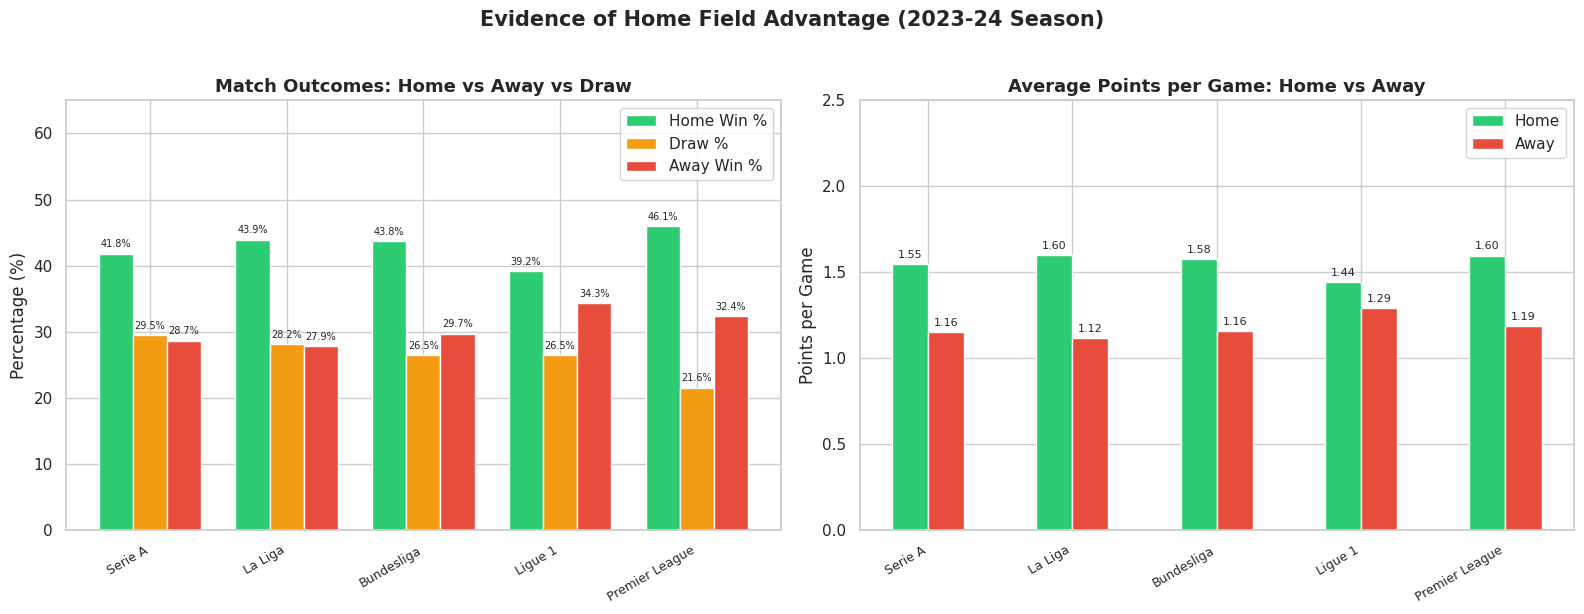


In every league, teams win more often at home and earn more points per game.


In [ ]:
import seaborn as sns

sns.set_theme(style='whitegrid')  # clean grid style
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # side-by-side panels

leagues = stats_df['League']
x = np.arange(len(leagues))  # x positions for bars
bar_width = 0.25

# panel 1: win/draw/loss percentages per league
bars1 = axes[0].bar(x - bar_width, stats_df['Home Win %'], bar_width, label='Home Win %', color='#2ecc71')
bars2 = axes[0].bar(x, stats_df['Draw %'], bar_width, label='Draw %', color='#f39c12')
bars3 = axes[0].bar(x + bar_width, stats_df['Away Win %'], bar_width, label='Away Win %', color='#e74c3c')

axes[0].set_title('Match Outcomes: Home vs Away vs Draw', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(leagues, rotation=30, ha='right', fontsize=9)
axes[0].legend()
axes[0].set_ylim(0, 65)

# annotate each bar with its value
for bar_group in [bars1, bars2, bars3]:
    for bar in bar_group:
        height = bar.get_height()
        axes[0].annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                         xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=7)

# panel 2: avg points per game, home vs away
bars4 = axes[1].bar(x - bar_width/2, stats_df['Avg Home Pts/Game'], bar_width, label='Home', color='#2ecc71')
bars5 = axes[1].bar(x + bar_width/2, stats_df['Avg Away Pts/Game'], bar_width, label='Away', color='#e74c3c')

axes[1].set_title('Average Points per Game: Home vs Away', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Points per Game')
axes[1].set_xticks(x)
axes[1].set_xticklabels(leagues, rotation=30, ha='right', fontsize=9)
axes[1].legend()
axes[1].set_ylim(0, 2.5)

# annotate each bar with its value
for bar_group in [bars4, bars5]:
    for bar in bar_group:
        height = bar.get_height()
        axes[1].annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                         xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)

plt.suptitle('Evidence of Home Field Advantage (2023-24 Season)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nIn every league, teams win more often at home and earn more points per game.')

## Step 4: Further investigation on home field advantage: To what extend does playing at the home field affect the home team's score

In 3.1, it is shown that home field advanatge exist. In other words, home team are more likely to win than away team. To further investigate to what extend does playing at home field affects the scores, the distribtiion of the net home team scores will be analysis with the use of box and whisker plot, where minimum, maximum, lower quartile, upper quartile, median and outliers will be visualised.  

The 'Net Home Points' will be calculated as the following:  
Home Points - Away Points  
(Negative if home points < away points)



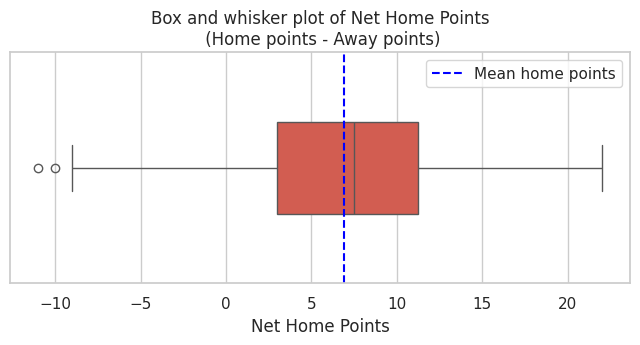

82.29166666666666
In the box and whisker plot, it shows the distribution of the home team advantage in general with the data we collected over the five leagues.
In the graph, it shows the minimum, maximum, lower quartiles, upper quartiles as well as 
the median, with the mean of home team net score represented by the blue line.
Overall, there are 82.29% positive net score.

Interquartile range (IQR)
________________________________________________________________________________________________________________________
The IQR describe the middle 50% of the dataset. 
In the graph, the entire IQR lies to the right of the zero-point, which again confirm 
home team advantage exists, since the lower quatile of the net home score is also positive.
The IQR also shows that 50% home team will score a positive net score between +3 and +11.

Mean and median
________________________________________________________________________________________________________________________
As seen in the graph

In [ ]:
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns

analysis = pd.DataFrame(index = computed.index) # store in another variable to avoid overwrite
analysis['home_team_advantage'] = computed['home_points'] - computed['away_points']

data_analysis = analysis.describe()
mean = data_analysis.loc['mean', 'home_team_advantage']
figure, axis = plt.subplots(figsize = (8,3))
# plot the box and whisker plot of the data, no need to sort the data, as it is sorted by itself
sns.boxplot(analysis['home_team_advantage'], orient = 'h', width = 0.4, color = '#e74c3c')
axis.axvline(x = mean, color = 'blue', linestyle = '--', label = 'Mean home points')
plt.legend()
axis.set_title('Box and whisker plot of Net Home Points\n (Home points - Away points)')
axis.set_xlabel('Net Home Points')
plt.show()

# analysis of the data and the plotted plot

count = data_analysis.loc['count', 'home_team_advantage']
std = data_analysis.loc['std', 'home_team_advantage']
min = data_analysis.loc['min', 'home_team_advantage']
lower_quartile = data_analysis.loc['25%', 'home_team_advantage']
median = data_analysis.loc['50%', 'home_team_advantage']
upper_quartile = data_analysis.loc['75%', 'home_team_advantage']
max = data_analysis.loc['max', 'home_team_advantage']

# counting how many positive net score
positive_score = []
for data in analysis['home_team_advantage']:
  if data > 0:
    positive_score.append(data)
length = len(positive_score)
rate = (length / count) * 100


# analysis outliers, 25%, median, 75%
print('In the box and whisker plot, it shows the distribution of the home team ' +
      'advantage in general with the data we collected over the five leagues.\n'+
      'In the graph, it shows the minimum, maximum, lower quartiles, upper quartiles as well as \n' +
      'the median, with the mean of home team net score represented by the blue line.')
print(f'Overall, there are {rate:.2f}% positive net score.\n')

print('Interquartile range (IQR)')
print('__'*60)

# computing interquartiles range
inter_quartile = upper_quartile - lower_quartile


print('The IQR describe the middle 50% of the dataset. \n'+
      'In the graph, the entire IQR lies to the right of the zero-point, which again confirm \n' +
      'home team advantage exists, since the lower quatile of the net home score is also positive.')
print(f'The IQR also shows that 50% home team will score a positive net score between +{round(lower_quartile)} and +{round(upper_quartile)}.\n')


#analysing the median and the mean
print('Mean and median')
print('__'*60)
if median == mean:
  print('As seen in the graph, the median and the mean is euqal, which suggests that the distribution ' +
        'is symmetric. In other words, the distribution is equally balenced.')
elif median > mean:
  print('As seen in the graph, the median is larger than the mean, which suggests that the distribution ' +
        'is negatively skewed.\n' 'In other words, the data consists of left-tailed outliers, causing the overall mean ' +
        'to be lower than the median.\n')
else:
  print('As seen in the graph, the median is lower than the mean, which suggests that the distribution \n' +
        'is positively skewed. In other woeds, the data consists of right-tailed outliers, causing the overall mean \n' +
        'to be hgiher than the median.\n')

#outliers
# calucating number of outliers
lower_bound = lower_quartile - 1.5 * inter_quartile
upper_bound = upper_quartile + 1.5 * inter_quartile

outliers = []
for data in analysis['home_team_advantage']:
  if data < lower_bound or data > upper_bound:
    outliers.append(data)
#print(outliers)
num_outliers = len(outliers)
print('Outliers')
print('__'*60)
print(f'As indicated by the distribution, there are some left-tailed outliers. There are {num_outliers} outliers, {outliers} respectively.\n')
if len(outliers) != 0:
  print('The existence of outliers suggests that while home team advantage exists, underperforming can still occur, with a \n' +
        'relatively lower percentage. \n')
# summary of this box and whisker ploy
print('Conclusion:')
print('__'*60)
print(f'Home field advantage affects the score to a significant rate. The data suggests that there is {rate:.2f}\n' +
      f'chance that home team will gain a positive net score point in a match, with 50% scoring between +{round(lower_quartile)} and +{round(upper_quartile)}.\n'
      f'The existance of left-tailed outliers suggests that underperfomance (scoring below {round(lower_bound)}) will also occur. \n')



## Step 5: Home Field Advantage vs Stadium Capacity
Does a larger stadium capacity mean a larger home field advantage? We analyze HFA using two metrics:
1. **Points Difference**: Home Points - Away Points
2. **Goal Difference**: Home GD - Away GD

In [ ]:
import matplotlib.pyplot as plt
import glob

team_map = dict(zip(teams_df['team_id'], teams_df['name']))

# glob finds all stadium CSVs matching the pattern (one per league)
# so we don't have to hardcode each filename manually
stadium_files = glob.glob('unprocessed/stadiums/*_2023_24.csv')

# read each league's stadium file and combine into one DataFrame
stadiums_list = [pd.read_csv(f) for f in stadium_files]
stadiums_df = pd.concat(stadiums_list, ignore_index=True)

# add human-readable team names to the standings
computed['team_name'] = computed['team_id'].map(team_map)

# join standings with stadium capacity on team name
hfa_df = computed.merge(stadiums_df[['Team', 'Capacity']], left_on='team_name', right_on='Team', how='inner')
missing_teams = set(computed['team_name']) - set(hfa_df['Team'])
if missing_teams:
    print('Warning: Could not match capacities for:', missing_teams)

# compute home field advantage metrics
hfa_df['HFA_Points'] = hfa_df['home_points'] - hfa_df['away_points']  # points gap
hfa_df['HFA_GD'] = hfa_df['home_goal_difference'] - hfa_df['away_goal_difference']  # goal diff gap

print(f'Successfully joined capacity data for {len(hfa_df)} out of {len(computed)} teams.')
hfa_df[['Team', 'Capacity', 'home_points', 'away_points', 'HFA_Points', 'HFA_GD']].head(10)


Successfully joined capacity data for 96 out of 96 teams.


,Team,Capacity,home_points,away_points,HFA_Points,HFA_GD
0,FC Internazionale Milano,75710,46,48,-2,-1
1,AC Milan,75710,40,35,5,15
2,Juventus FC,41507,40,31,9,7
3,Atalanta BC,15222,41,28,13,22
4,Bologna FC 1909,36532,41,27,14,20
5,AS Roma,67585,40,23,17,19
6,SS Lazio,67585,34,27,7,8
7,ACF Fiorentina,43118,35,25,10,15
8,SSC Napoli,54732,25,28,-3,-13
9,Torino FC,28177,33,20,13,18


In [ ]:
# calculate Pearson correlations
corr_points = hfa_df['Capacity'].corr(hfa_df['HFA_Points'])
corr_gd = hfa_df['Capacity'].corr(hfa_df['HFA_GD'])

print(f'Pearson Correlation — Capacity vs HFA (Points): {corr_points:.3f}')
print(f'Pearson Correlation — Capacity vs HFA (Goal Diff): {corr_gd:.3f}')

Pearson Correlation — Capacity vs HFA (Points): 0.139
Pearson Correlation — Capacity vs HFA (Goal Diff): 0.128


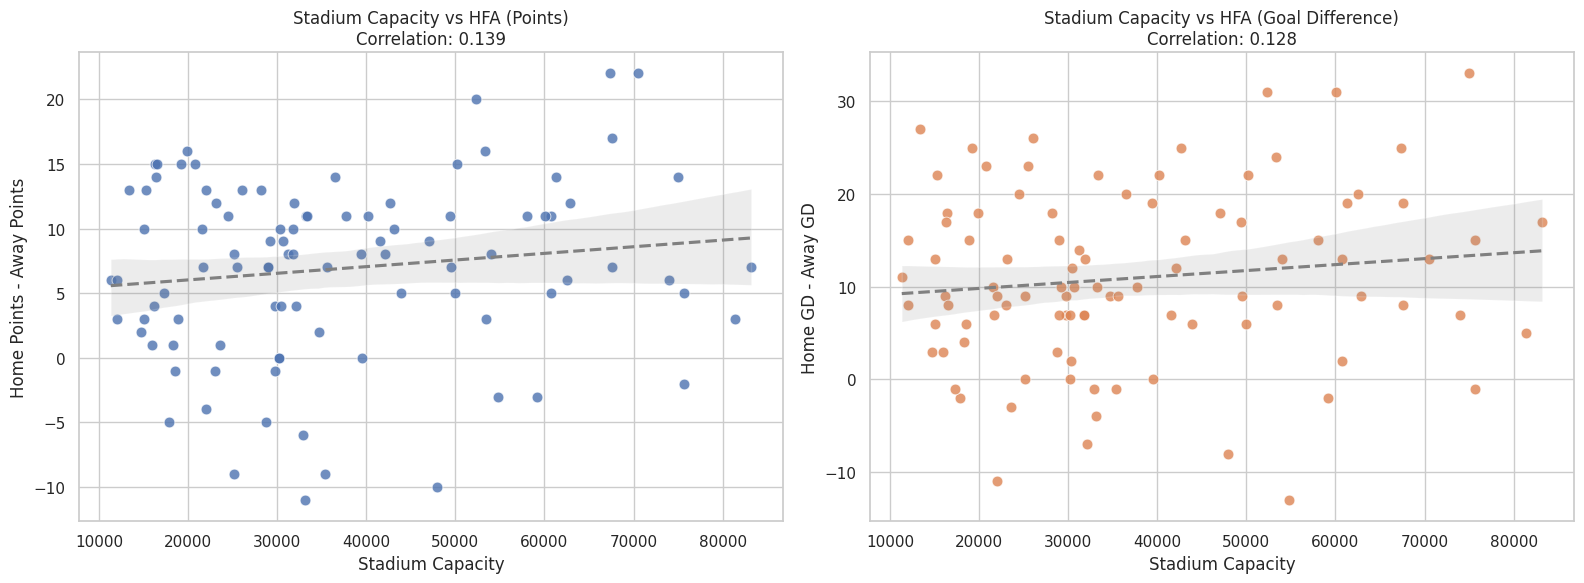

In [ ]:
sns.set_theme(style='whitegrid')  # clean grid style
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # side-by-side scatter plots

# scatter: capacity vs HFA points + regression line
sns.scatterplot(
    data=hfa_df, x='Capacity', y='HFA_Points',
    ax=axes[0], s=60, alpha=0.8, color='#4c72b0'
)
sns.regplot(data=hfa_df, x='Capacity', y='HFA_Points', ax=axes[0], scatter=False, color='gray', line_kws={'linestyle':'--'})
axes[0].set_title(f'Stadium Capacity vs HFA (Points)\nCorrelation: {corr_points:.3f}')
axes[0].set_xlabel('Stadium Capacity')
axes[0].set_ylabel('Home Points - Away Points')

# scatter: capacity vs HFA goal difference + regression line
sns.scatterplot(
    data=hfa_df, x='Capacity', y='HFA_GD',
    ax=axes[1], s=60, alpha=0.8, color='#dd8452'
)
sns.regplot(data=hfa_df, x='Capacity', y='HFA_GD', ax=axes[1], scatter=False, color='gray', line_kws={'linestyle':'--'})
axes[1].set_title(f'Stadium Capacity vs HFA (Goal Difference)\nCorrelation: {corr_gd:.3f}')
axes[1].set_xlabel('Stadium Capacity')
axes[1].set_ylabel('Home GD - Away GD')

plt.tight_layout()
plt.show()

## Step 6: Hypothesis Testing: Does Stadium Capacity Matter?
We formally compare two competing hypotheses:
- **H₀ (Null)**: Stadium capacity has **no effect** on home field advantage (correlation = 0)
- **H₁ (Alternative)**: Stadium capacity **does affect** home field advantage (correlation ≠ 0)

We use two methods:
1. **Pearson correlation test**: gives a p-value for the null hypothesis
2. **Permutation test**: shuffles capacity randomly 10,000 times to build a null distribution and checks where the observed correlation falls in the rejection zone

In [ ]:
from scipy import stats

alpha = 0.05  # significance level

# pearson test: does capacity correlate with HFA (points)?
r_pts, p_pts = stats.pearsonr(hfa_df['Capacity'], hfa_df['HFA_Points'])
print('=' * 60)
print('HYPOTHESIS TEST: Capacity vs HFA (Points)')
print('=' * 60)
print(f'  Pearson r = {r_pts:.4f}')
print(f'  p-value   = {p_pts:.4f}')
if p_pts < alpha:
    print(f'  -> p < {alpha}: REJECT H0. Capacity significantly affects HFA (Points).')
else:
    print(f'  -> p >= {alpha}: FAIL TO REJECT H0. No significant effect of capacity on HFA (Points).')

# pearson test: does capacity correlate with HFA (goal difference)?
r_gd, p_gd = stats.pearsonr(hfa_df['Capacity'], hfa_df['HFA_GD'])
print()
print('=' * 60)
print('HYPOTHESIS TEST: Capacity vs HFA (Goal Difference)')
print('=' * 60)
print(f'  Pearson r = {r_gd:.4f}')
print(f'  p-value   = {p_gd:.4f}')
if p_gd < alpha:
    print(f'  -> p < {alpha}: REJECT H0. Capacity significantly affects HFA (GD).')
else:
    print(f'  -> p >= {alpha}: FAIL TO REJECT H0. No significant effect of capacity on HFA (GD).')


HYPOTHESIS TEST: Capacity vs HFA (Points)
  Pearson r = 0.1389
  p-value   = 0.1771
  -> p >= 0.05: FAIL TO REJECT H0. No significant effect of capacity on HFA (Points).

HYPOTHESIS TEST: Capacity vs HFA (Goal Difference)
  Pearson r = 0.1276
  p-value   = 0.2153
  -> p >= 0.05: FAIL TO REJECT H0. No significant effect of capacity on HFA (GD).


In [ ]:
# permutation test: shuffle capacity 10,000 times to build a null distribution
# if capacity doesn't matter (H0), shuffled correlations should look similar to observed

np.random.seed(42)  # reproducibility
n_perms = 10000
observed_r_pts = r_pts
observed_r_gd = r_gd

perm_r_pts = []
perm_r_gd = []
capacity_values = hfa_df['Capacity'].values.copy()

# shuffle capacity and recompute correlation each time
for _ in range(n_perms):
    shuffled = np.random.permutation(capacity_values)
    perm_r_pts.append(np.corrcoef(shuffled, hfa_df['HFA_Points'].values)[0, 1])
    perm_r_gd.append(np.corrcoef(shuffled, hfa_df['HFA_GD'].values)[0, 1])

perm_r_pts = np.array(perm_r_pts)
perm_r_gd = np.array(perm_r_gd)

# two-tailed p-value: how often does shuffled |r| beat observed |r|?
perm_p_pts = np.mean(np.abs(perm_r_pts) >= np.abs(observed_r_pts))
perm_p_gd = np.mean(np.abs(perm_r_gd) >= np.abs(observed_r_gd))

print('=' * 60)
print('PERMUTATION TEST (10,000 shuffles)')
print('=' * 60)
print(f'  HFA Points:  observed r = {observed_r_pts:.4f}, permutation p = {perm_p_pts:.4f}')
print(f'  HFA GD:      observed r = {observed_r_gd:.4f}, permutation p = {perm_p_gd:.4f}')

PERMUTATION TEST (10,000 shuffles)
  HFA Points:  observed r = 0.1389, permutation p = 0.1819
  HFA GD:      observed r = 0.1276, permutation p = 0.2190


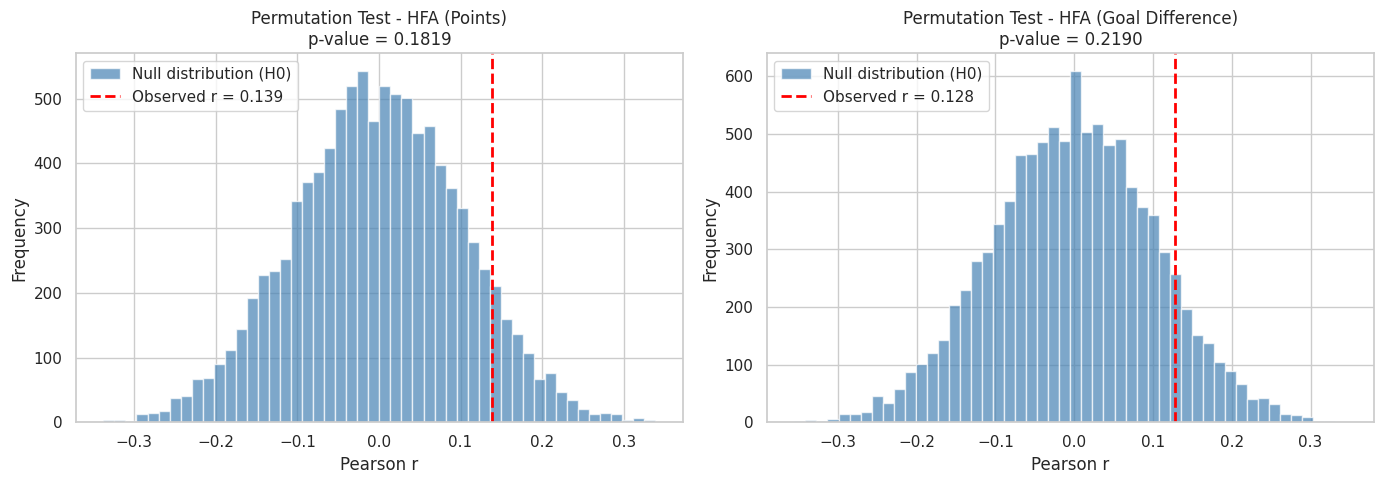

In [ ]:
# plot null distribution (blue histogram) vs observed correlation (red line)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# HFA points permutation histogram
axes[0].hist(perm_r_pts, bins=50, color='steelblue', alpha=0.7, edgecolor='white', label='Null distribution (H0)')
axes[0].axvline(observed_r_pts, color='red', linewidth=2, linestyle='--', label=f'Observed r = {observed_r_pts:.3f}')
axes[0].set_title(f'Permutation Test - HFA (Points)\np-value = {perm_p_pts:.4f}')
axes[0].set_xlabel('Pearson r')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# HFA goal difference permutation histogram
axes[1].hist(perm_r_gd, bins=50, color='steelblue', alpha=0.7, edgecolor='white', label='Null distribution (H0)')
axes[1].axvline(observed_r_gd, color='red', linewidth=2, linestyle='--', label=f'Observed r = {observed_r_gd:.3f}')
axes[1].set_title(f'Permutation Test - HFA (Goal Difference)\np-value = {perm_p_gd:.4f}')
axes[1].set_xlabel('Pearson r')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()


After running 10000 simulations with randomly assigned stadium capacity, we obtain the null distribution for the Pearson r value of the hypothesis that stadium capacity does not affect the Home Field advantage. Compare that with the original Pearson r to see how likely the outcome is vs the null hypothesis.

In [ ]:
# final summary table
def conclusion(p, alpha=0.05):
    return 'Reject H0 - Capacity matters' if p < alpha else 'Fail to Reject H0 - No significant effect'

print('FINAL SUMMARY:')
print(f'\n{"Metric":<20} | {"Pearson r":>10} | {"Pearson p":>10} | {"Perm p":>8} | Conclusion')
print('-' * 80)
print(f'{"HFA (Points)":<20} | {r_pts:>10.4f} | {p_pts:>10.4f} | {perm_p_pts:>8.4f} | {conclusion(p_pts)}')
print(f'{"HFA (Goal Diff)":<20} | {r_gd:>10.4f} | {p_gd:>10.4f} | {perm_p_gd:>8.4f} | {conclusion(p_gd)}')
print(f'\nSignificance level: alpha = {alpha}')
print()
if p_pts >= alpha and p_gd >= alpha:
    print('CONCLUSION: The data does NOT provide enough evidence to reject the null hypothesis.')
    print('   Stadium capacity does NOT significantly affect home field advantage.')
elif p_pts < alpha and p_gd < alpha:
    print('CONCLUSION: The data provides strong evidence to reject the null hypothesis for BOTH metrics.')
    print('   Stadium capacity DOES significantly affect home field advantage.')
else:
    print('CONCLUSION: Mixed results - one metric is significant while the other is not.')
    print('   Further investigation may be needed.')

FINAL SUMMARY:

Metric               |  Pearson r |  Pearson p |   Perm p | Conclusion
--------------------------------------------------------------------------------
HFA (Points)         |     0.1389 |     0.1771 |   0.1819 | Fail to Reject H0 - No significant effect
HFA (Goal Diff)      |     0.1276 |     0.2153 |   0.2190 | Fail to Reject H0 - No significant effect

Significance level: alpha = 0.05

CONCLUSION: The data does NOT provide enough evidence to reject the null hypothesis.
   Stadium capacity does NOT significantly affect home field advantage.


## Step 7: Fill Rate Analysis — Does Higher Attendance Rate Affect Home Field Advantage?
Fill Rate = Average Attendance / Capacity. This measures how "full" a stadium typically is, regardless of its size.
We test whether fill rate is a better predictor of HFA than raw capacity.

- **H₀ (Null)**: Fill rate has **no effect** on home field advantage
- **H₁ (Alternative)**: Fill rate **does affect** home field advantage

In [ ]:
# compute fill rate per team
stadiums_df['Fill_Rate'] = stadiums_df['Average_Attendance'] / stadiums_df['Capacity']

# merge fill rate into HFA dataframe
hfa_fill = hfa_df.merge(
    stadiums_df[['Team', 'Average_Attendance', 'Fill_Rate']],
    on='Team',
    how='inner'
)

print(f'Teams with fill rate data: {len(hfa_fill)}')
print(f'\nFill Rate statistics:')
print(hfa_fill['Fill_Rate'].describe())
print(f'\nTop 5 highest fill rates:')
print(hfa_fill[['Team', 'Capacity', 'Average_Attendance', 'Fill_Rate', 'HFA_Points', 'HFA_GD']].sort_values('Fill_Rate', ascending=False).head())
print(f'\nBottom 5 lowest fill rates:')
print(hfa_fill[['Team', 'Capacity', 'Average_Attendance', 'Fill_Rate', 'HFA_Points', 'HFA_GD']].sort_values('Fill_Rate', ascending=True).head())


Teams with fill rate data: 96

Fill Rate statistics:
count    96.000000
mean      0.875627
std       0.124751
min       0.401447
25%       0.808358
50%       0.908267
75%       0.981093
max       1.000053
Name: Fill_Rate, dtype: float64

Top 5 highest fill rates:
                     Team  Capacity  Average_Attendance  Fill_Rate  \
64    Racing Club de Lens     37705               37707   1.000053   
47  1. FC Heidenheim 1846     15000               15000   1.000000   
42      FC Bayern München     75000               75000   1.000000   
84        West Ham United     62500               62464   0.999424   
44      Borussia Dortmund     81365               81305   0.999263   

    HFA_Points  HFA_GD  
64          11      10  
47          10      13  
42          14      33  
84           6      20  
44           3       5  

Bottom 5 lowest fill rates:
                   Team  Capacity  Average_Attendance  Fill_Rate  HFA_Points  \
59         AS Monaco FC     18523                7436   

In [ ]:
# pearson test: does fill rate correlate with HFA (points)?
r_fill_pts, p_fill_pts = stats.pearsonr(hfa_fill['Fill_Rate'], hfa_fill['HFA_Points'])
print('=' * 60)
print('HYPOTHESIS TEST: Fill Rate vs HFA (Points)')
print('=' * 60)
print(f'  Pearson r = {r_fill_pts:.4f}')
print(f'  p-value   = {p_fill_pts:.4f}')
if p_fill_pts < alpha:
    print(f'  -> p < {alpha}: REJECT H0. Fill rate significantly affects HFA (Points).')
else:
    print(f'  -> p >= {alpha}: FAIL TO REJECT H0. No significant effect of fill rate on HFA (Points).')

# pearson test: does fill rate correlate with HFA (goal difference)?
r_fill_gd, p_fill_gd = stats.pearsonr(hfa_fill['Fill_Rate'], hfa_fill['HFA_GD'])
print()
print('=' * 60)
print('HYPOTHESIS TEST: Fill Rate vs HFA (Goal Difference)')
print('=' * 60)
print(f'  Pearson r = {r_fill_gd:.4f}')
print(f'  p-value   = {p_fill_gd:.4f}')
if p_fill_gd < alpha:
    print(f'  -> p < {alpha}: REJECT H0. Fill rate significantly affects HFA (GD).')
else:
    print(f'  -> p >= {alpha}: FAIL TO REJECT H0. No significant effect of fill rate on HFA (GD).')



HYPOTHESIS TEST: Fill Rate vs HFA (Points)
  Pearson r = 0.2128
  p-value   = 0.0374
  -> p < 0.05: REJECT H0. Fill rate significantly affects HFA (Points).

HYPOTHESIS TEST: Fill Rate vs HFA (Goal Difference)
  Pearson r = 0.2182
  p-value   = 0.0327
  -> p < 0.05: REJECT H0. Fill rate significantly affects HFA (GD).


In [ ]:
np.random.seed(42)  # reproducibility
n_perms = 10000
obs_r_fill_pts = r_fill_pts
obs_r_fill_gd = r_fill_gd

perm_r_fill_pts = []
perm_r_fill_gd = []
fill_values = hfa_fill['Fill_Rate'].values.copy()

# shuffle fill rate and recompute correlation each time
for _ in range(n_perms):
    shuffled = np.random.permutation(fill_values)
    perm_r_fill_pts.append(np.corrcoef(shuffled, hfa_fill['HFA_Points'].values)[0, 1])
    perm_r_fill_gd.append(np.corrcoef(shuffled, hfa_fill['HFA_GD'].values)[0, 1])

perm_r_fill_pts = np.array(perm_r_fill_pts)
perm_r_fill_gd = np.array(perm_r_fill_gd)

# two-tailed p-value: how often does shuffled |r| beat observed |r|?
perm_p_fill_pts = np.mean(np.abs(perm_r_fill_pts) >= np.abs(obs_r_fill_pts))
perm_p_fill_gd = np.mean(np.abs(perm_r_fill_gd) >= np.abs(obs_r_fill_gd))

print('=' * 60)
print('PERMUTATION TEST - FILL RATE (10,000 shuffles)')
print('=' * 60)
print(f'  HFA Points:  observed r = {obs_r_fill_pts:.4f}, permutation p = {perm_p_fill_pts:.4f}')
print(f'  HFA GD:      observed r = {obs_r_fill_gd:.4f}, permutation p = {perm_p_fill_gd:.4f}')


PERMUTATION TEST - FILL RATE (10,000 shuffles)
  HFA Points:  observed r = 0.2128, permutation p = 0.0346
  HFA GD:      observed r = 0.2182, permutation p = 0.0320


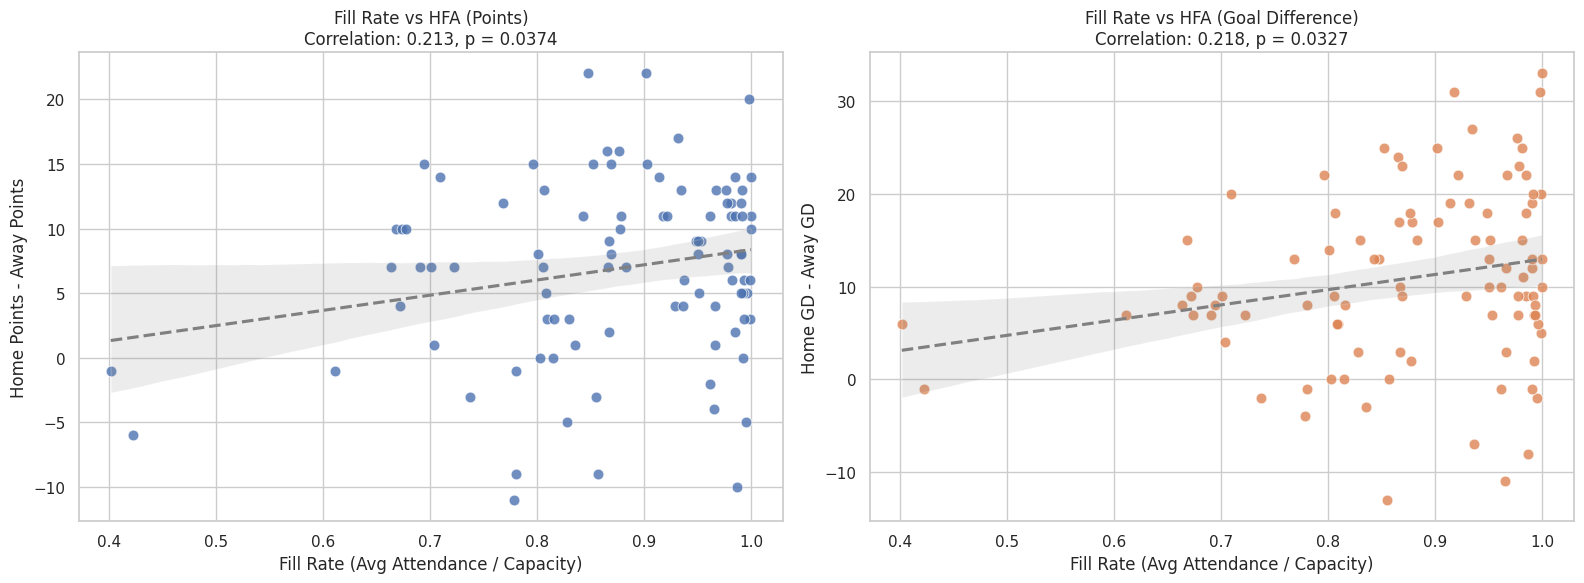

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# plot 1: Fill Rate vs Points
sns.scatterplot(
    data=hfa_fill, x='Fill_Rate', y='HFA_Points',
    ax=axes[0], s=60, alpha=0.8, color='#4c72b0'
)
sns.regplot(data=hfa_fill, x='Fill_Rate', y='HFA_Points', ax=axes[0], scatter=False, color='gray', line_kws={'linestyle':'--'})
axes[0].set_title(f'Fill Rate vs HFA (Points)\nCorrelation: {r_fill_pts:.3f}, p = {p_fill_pts:.4f}')
axes[0].set_xlabel('Fill Rate (Avg Attendance / Capacity)')
axes[0].set_ylabel('Home Points - Away Points')

# plot 2: Fill Rate vs GD
sns.scatterplot(
    data=hfa_fill, x='Fill_Rate', y='HFA_GD',
    ax=axes[1], s=60, alpha=0.8, color='#dd8452'
)
sns.regplot(data=hfa_fill, x='Fill_Rate', y='HFA_GD', ax=axes[1], scatter=False, color='gray', line_kws={'linestyle':'--'})
axes[1].set_title(f'Fill Rate vs HFA (Goal Difference)\nCorrelation: {r_fill_gd:.3f}, p = {p_fill_gd:.4f}')
axes[1].set_xlabel('Fill Rate (Avg Attendance / Capacity)')
axes[1].set_ylabel('Home GD - Away GD')

plt.tight_layout()
plt.show()

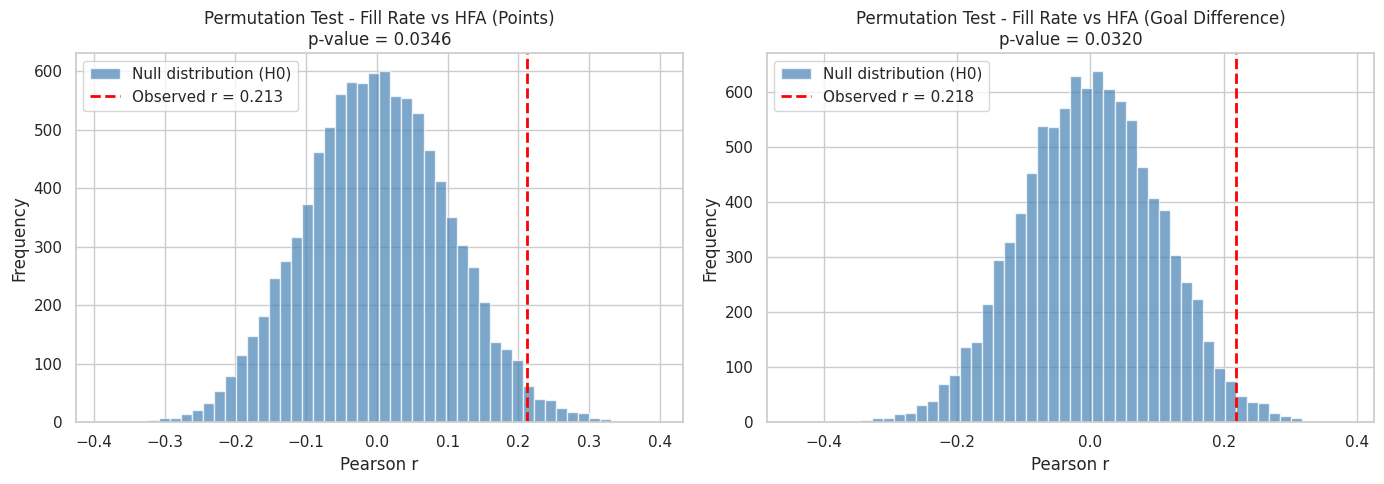

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# fill rate vs HFA points permutation histogram
axes[0].hist(perm_r_fill_pts, bins=50, color='steelblue', alpha=0.7, edgecolor='white', label='Null distribution (H0)')
axes[0].axvline(obs_r_fill_pts, color='red', linewidth=2, linestyle='--', label=f'Observed r = {obs_r_fill_pts:.3f}')
axes[0].set_title(f'Permutation Test - Fill Rate vs HFA (Points)\np-value = {perm_p_fill_pts:.4f}')
axes[0].set_xlabel('Pearson r')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# fill rate vs HFA goal difference permutation histogram
axes[1].hist(perm_r_fill_gd, bins=50, color='steelblue', alpha=0.7, edgecolor='white', label='Null distribution (H0)')
axes[1].axvline(obs_r_fill_gd, color='red', linewidth=2, linestyle='--', label=f'Observed r = {obs_r_fill_gd:.3f}')
axes[1].set_title(f'Permutation Test - Fill Rate vs HFA (Goal Difference)\np-value = {perm_p_fill_gd:.4f}')
axes[1].set_xlabel('Pearson r')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# print comparison table: capacity vs fill rate as HFA predictors
print('=' * 90)
print('COMPARISON: Stadium Capacity vs Fill Rate as Predictors of Home Field Advantage')
print('=' * 90)

print(f'\n{"Factor":<20} | {"Metric":<18} | {"Pearson r":>10} | {"Pearson p":>10} | {"Perm p":>8} | Conclusion')
print('-' * 90)

# print each row with inline conclusion
for factor, metric, r, p, perm_p in [
    ('Capacity',  'HFA (Points)',    r_pts,      p_pts,      perm_p_pts),
    ('Capacity',  'HFA (Goal Diff)', r_gd,       p_gd,       perm_p_gd),
    ('Fill Rate', 'HFA (Points)',    r_fill_pts, p_fill_pts, perm_p_fill_pts),
    ('Fill Rate', 'HFA (Goal Diff)', r_fill_gd,  p_fill_gd,  perm_p_fill_gd),
]:
    if p < alpha:
        result = 'Reject H0 - Significant effect'
    else:
        result = 'Fail to Reject H0 - No significant effect'
    print(f'{factor:<20} | {metric:<18} | {r:>10.4f} | {p:>10.4f} | {perm_p:>8.4f} | {result}')

print(f'\nSignificance level: alpha = {alpha}')

# decide which factor is the stronger predictor based on absolute correlation
print('CONCLUSION:')
if abs(r_fill_pts) > abs(r_pts) or abs(r_fill_gd) > abs(r_gd):
    print('Fill Rate shows a STRONGER correlation with HFA than raw Capacity.')
    print('This suggests that how FULL a stadium is matters more than how BIG it is.')
else:
    print('Raw Capacity shows a STRONGER correlation with HFA than Fill Rate.')
    print('This suggests that how BIG a stadium is matters more than how FULL it is.')

COMPARISON: Stadium Capacity vs Fill Rate as Predictors of Home Field Advantage

Factor               | Metric             |  Pearson r |  Pearson p |   Perm p | Conclusion
------------------------------------------------------------------------------------------
Capacity             | HFA (Points)       |     0.1389 |     0.1771 |   0.1819 | Fail to Reject H0 - No significant effect
Capacity             | HFA (Goal Diff)    |     0.1276 |     0.2153 |   0.2190 | Fail to Reject H0 - No significant effect
Fill Rate            | HFA (Points)       |     0.2128 |     0.0374 |   0.0346 | Reject H0 - Significant effect
Fill Rate            | HFA (Goal Diff)    |     0.2182 |     0.0327 |   0.0320 | Reject H0 - Significant effect

Significance level: alpha = 0.05
CONCLUSION:
Fill Rate shows a STRONGER correlation with HFA than raw Capacity.
This suggests that how FULL a stadium is matters more than how BIG it is.


## Step 8: Conclusion
### Key Findings

1. **Home Field Advantage is real and consistent.**
   Across all five leagues, home teams earned significantly more points, scored more goals, and won more matches than away teams. This confirms a well-documented phenomenon in football: playing at home provides a tangible competitive edge.

2. With reference to the box and whisker plot, 50% home teams are likely to win 3 to 11 points more than away team, with maximum 22 points more. This suggests that the home team advantage plays an siginificant role in the scores that the home team wins.    

3. **Stadium capacity alone does not explain HFA.**
   Despite the intuitive assumption that larger stadiums and therefore larger crowds would amplify home advantage, the data tells a different story. Neither the Pearson correlation test nor the permutation test found a statistically significant relationship between raw stadium capacity and HFA metrics (points difference or goal difference). With p-values well above 0.05, we **failed to reject** the null hypothesis: bigger stadiums do not automatically translate into a stronger home advantage.

4. **Fill rate is a statistically significant predictor of HFA.**
  Fill rate showed a significant positive correlation with both HFA points (r ≈ 0.21, p ≈ 0.037) and HFA goal difference (r ≈ 0.22, p ≈ 0.033). Both the Pearson test and the permutation test confirmed this at the α = 0.05 level, allowing us to **reject** the null hypothesis. This means that stadiums which are proportionally fuller tend to produce a stronger home advantage, regardless of their absolute size.

# Sources

European top 5 leagues 2023-2024:
https://www.kaggle.com/datasets/kamrangayibov/football-data-european-top-5-leagues

Additional data: Attendance and capacity: created manually with data from Wikipedia pages:
- https://en.wikipedia.org/wiki/2023%E2%80%9324_Premier_League
- https://en.wikipedia.org/wiki/2023%E2%80%9324_La_Liga
- https://en.wikipedia.org/wiki/2023%E2%80%9324_Bundesliga
- https://en.wikipedia.org/wiki/2023%E2%80%9324_Serie_A
- https://en.wikipedia.org/wiki/2023%E2%80%9324_Ligue_1

## Dataset Information
- Last Updated: 2025-05-06
- Source: football-data.org API
- License: CC0: Public Domain